In [1]:

# =============================================================================
# SECTION 1 — IMPORTS & SETUP
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

# Consistent plot style throughout
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    })

COLORS = {
    'safe':      '#2563B0',
    'grey':      '#F59E0B',
    'distress':  '#DC2626',
    'neutral':   '#6B7280',
    'challenger':'#059669',
}

print("=" * 65)
print("  ALTMAN Z-SCORE: REPLICATION & INDEPENDENT VALIDATION")
print("  Vartika Srivastava | Moody's MRG Application Project")
print("=" * 65)


  ALTMAN Z-SCORE: REPLICATION & INDEPENDENT VALIDATION
  Vartika Srivastava | Moody's MRG Application Project



[1/6] Loading and inspecting data...

Dataset shape        : 6,819 rows × 96 columns
Bankruptcy cases     : 220  (3.23%)
Non-bankruptcy cases : 6,599 (96.77%)
Missing values total : 0

  Column mapping resolved:
    X1 (Working Capital / TA) → 'Working Capital to Total Assets'
    X2 (Retained Earnings / TA) → 'Retained Earnings to Total Assets'
    X3 (EBIT / TA)             → 'Net Income to Total Assets'
    X4 (Equity / Liability)    → 'Equity to Liability'
    X5 (Net Sales / TA)        → 'Total Asset Turnover'


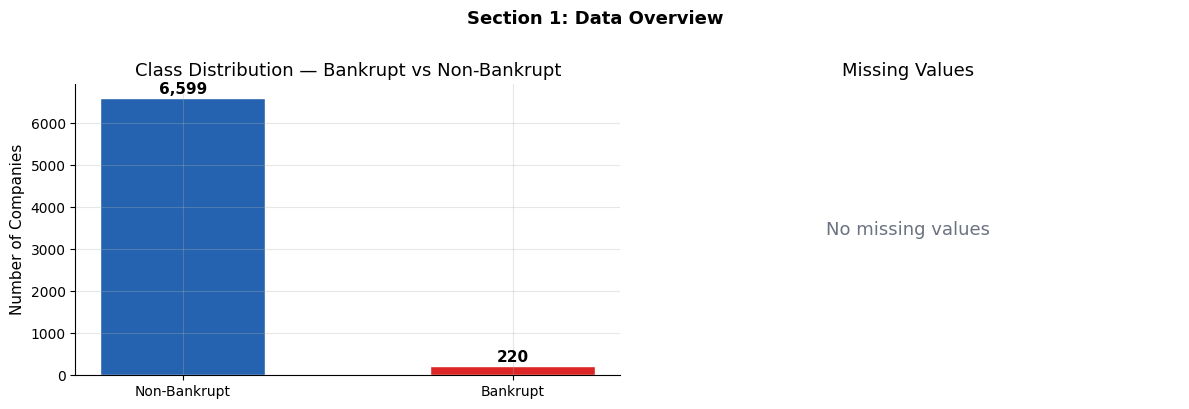

  → Figure saved: 01_data_overview.png


In [2]:

print("\n[1/6] Loading and inspecting data...\n")

df = pd.read_csv('/kaggle/input/datasets/fedesoriano/company-bankruptcy-prediction/data.csv')

# Strip ALL leading/trailing whitespace from column names — this dataset
# has a leading space on every column except 'Bankrupt?'
df.columns = df.columns.str.strip()

print(f"Dataset shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Bankruptcy cases     : {df['Bankrupt?'].sum():,}  ({df['Bankrupt?'].mean()*100:.2f}%)")
print(f"Non-bankruptcy cases : {(1-df['Bankrupt?']).sum():,} ({(1-df['Bankrupt?']).mean()*100:.2f}%)")
print(f"Missing values total : {df.isnull().sum().sum():,}")
# ── Robust column finder ────────────────────────────────────────────────────
# The dataset uses inconsistent capitalisation across versions on Kaggle.
# We search case-insensitively so the code works regardless of minor name drift.

def find_col(df_cols, *keywords):
    """
    Return the first column name whose lower-case form contains ALL keywords.
    Raises a clear error if nothing matches so debugging is easy.
    """
    cols_lower = [c.lower() for c in df_cols]
    for kw_set in keywords:          # try each keyword tuple in priority order
        if isinstance(kw_set, str):
            kw_set = (kw_set,)
        matches = [df_cols[i] for i, c in enumerate(cols_lower)
                   if all(k.lower() in c for k in kw_set)]
        if matches:
            return matches[0]
    raise KeyError(f"No column matching any of {keywords} found.\n"
                   f"Available columns: {list(df_cols)}")

cols = df.columns.tolist()

# Map Altman variables to dataset columns (multiple keyword tuples = fallbacks)
# Map Altman variables to dataset columns

X1_col = 'Working Capital to Total Assets'

X2_col = 'Retained Earnings to Total Assets'

X3_col = 'Net Income to Total Assets'

X4_col = 'Equity to Liability'

X5_col = 'Total Asset Turnover'

print(f"\n  Column mapping resolved:")
print(f"    X1 (Working Capital / TA) → '{X1_col}'")
print(f"    X2 (Retained Earnings / TA) → '{X2_col}'")
print(f"    X3 (EBIT / TA)             → '{X3_col}'")
print(f"    X4 (Equity / Liability)    → '{X4_col}'")
print(f"    X5 (Net Sales / TA)        → '{X5_col}'")
# --- Plot 1: Class distribution & missing values ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Bankrupt?'].value_counts()
bars = axes[0].bar(['Non-Bankrupt', 'Bankrupt'], counts.values,
                   color=[COLORS['safe'], COLORS['distress']], width=0.5, edgecolor='white')
axes[0].set_title('Class Distribution — Bankrupt vs Non-Bankrupt')
axes[0].set_ylabel('Number of Companies')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False).head(20)
if missing_pct.max() > 0:
    axes[1].barh(range(len(missing_pct)), missing_pct.values, color=COLORS['neutral'], alpha=0.7)
    axes[1].set_yticks(range(len(missing_pct)))
    axes[1].set_yticklabels([c[:30] for c in missing_pct.index], fontsize=8)
    axes[1].set_title('Missing Values (%) — Top 20 Columns')
    axes[1].set_xlabel('% Missing')
else:
    axes[1].text(0.5, 0.5, 'No missing values', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=13, color=COLORS['neutral'])
    axes[1].set_title('Missing Values')
    axes[1].axis('off')



plt.suptitle('Section 1: Data Overview', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("  → Figure saved: 01_data_overview.png")






[2/6] Replicating Altman Z-Score...

  Zone Distribution:
    Distress    :     1 companies (0.0%)
    Grey Zone   :     1 companies (0.0%)
    Safe        : 6,817 companies (100.0%)

  Z-Score Statistics by Actual Outcome:
            mean    std    min    50%    max
Bankrupt?                                   
0          5.135  0.229  0.959  5.128  6.143
1          4.723  0.330  3.108  4.788  5.663


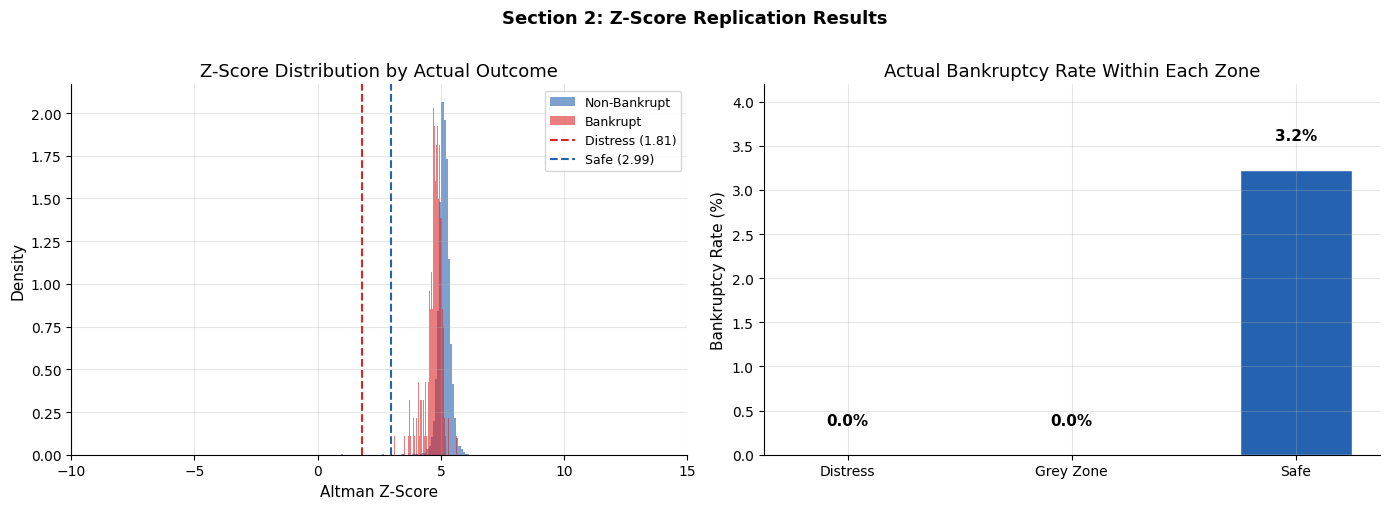

  → Figure saved: 02_zscore_replication.png


In [3]:
# =============================================================================
# SECTION 3 — VARIABLE MAPPING & Z-SCORE REPLICATION
# =============================================================================
# Following Altman (1968): "Financial Ratios, Discriminant Analysis and
# the Prediction of Corporate Bankruptcy", Journal of Finance.
#
# Z = 1.2·X1 + 1.4·X2 + 3.3·X3 + 0.6·X4 + 1.0·X5
# Map Altman variables to dataset columns

# Map Altman variables to dataset columns

# Map Altman variables to dataset columns

X1_col = 'Working Capital to Total Assets'

X2_col = 'Retained Earnings to Total Assets'

X3_col = 'Net Income to Total Assets'

X4_col = 'Equity to Liability'

X5_col = 'Total Asset Turnover'
print("\n[2/6] Replicating Altman Z-Score...\n")

# Build X1–X5 using the dynamically resolved column names
df['X1'] = pd.to_numeric(df[X1_col], errors='coerce').fillna(0)
df['X2'] = pd.to_numeric(df[X2_col], errors='coerce').fillna(0)
df['X3'] = pd.to_numeric(df[X3_col], errors='coerce').fillna(0)
df['X4'] = pd.to_numeric(df[X4_col], errors='coerce').fillna(0)
df['X5'] = pd.to_numeric(df[X5_col], errors='coerce').fillna(0)

# Replace infinities, then fill residual NaN with 0
altman_vars = ['X1', 'X2', 'X3', 'X4', 'X5']
df[altman_vars] = df[altman_vars].replace([np.inf, -np.inf], np.nan).fillna(0)

# Altman (1968) coefficients
WEIGHTS = {'X1': 1.2, 'X2': 1.4, 'X3': 3.3, 'X4': 0.6, 'X5': 1.0}

df['Z_Score'] = (
    WEIGHTS['X1'] * df['X1'] +
    WEIGHTS['X2'] * df['X2'] +
    WEIGHTS['X3'] * df['X3'] +
    WEIGHTS['X4'] * df['X4'] +
    WEIGHTS['X5'] * df['X5']
)

# Zone classification per Altman thresholds
THRESH_DISTRESS = 1.81
THRESH_SAFE     = 2.99

def classify_zone(z):
    if z > THRESH_SAFE:
        return 'Safe'
    elif z > THRESH_DISTRESS:
        return 'Grey Zone'
    else:
        return 'Distress'

df['Zone'] = df['Z_Score'].apply(classify_zone)

zone_order  = ['Distress', 'Grey Zone', 'Safe']
zone_counts = df['Zone'].value_counts()
print("  Zone Distribution:")
for zone in zone_order:
    n   = zone_counts.get(zone, 0)
    pct = n / len(df) * 100
    print(f"    {zone:<12}: {n:>5,} companies ({pct:.1f}%)")

print("\n  Z-Score Statistics by Actual Outcome:")
print(df.groupby('Bankrupt?')['Z_Score']
      .describe()[['mean', 'std', 'min', '50%', 'max']]
        .round(3).to_string())

# --- Plot 2: Z-Score distributions ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color, name in [(0, COLORS['safe'], 'Non-Bankrupt'),
                            (1, COLORS['distress'], 'Bankrupt')]:
    subset = df[df['Bankrupt?'] == label]['Z_Score'].clip(-10, 15)
    axes[0].hist(subset, bins=60, alpha=0.6, color=color, label=name, density=True)

for thresh, col, lbl in [(THRESH_DISTRESS, COLORS['distress'], f'Distress ({THRESH_DISTRESS})'),
                          (THRESH_SAFE,     COLORS['safe'],     f'Safe ({THRESH_SAFE})')]:
    axes[0].axvline(thresh, color=col, linestyle='--', linewidth=1.5, label=lbl)

axes[0].set_title('Z-Score Distribution by Actual Outcome')
axes[0].set_xlabel('Altman Z-Score')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)
axes[0].set_xlim(-10, 15)

bkrupt_rate = df.groupby('Zone')['Bankrupt?'].mean().reindex(zone_order) * 100
zone_colors = [COLORS['distress'], COLORS['grey'], COLORS['safe']]
bars = axes[1].bar(zone_order, bkrupt_rate.values, color=zone_colors, width=0.5, edgecolor='white')
axes[1].set_title('Actual Bankruptcy Rate Within Each Zone')
axes[1].set_ylabel('Bankruptcy Rate (%)')
axes[1].set_ylim(0, min(bkrupt_rate.max() * 1.3, 100))
for bar, val in zip(bars, bkrupt_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Section 2: Z-Score Replication Results', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_zscore_replication.png', dpi=150, bbox_inches='tight')
plt.show()
print("  → Figure saved: 02_zscore_replication.png")



[3/6] Validating model performance...

  Discriminatory Power:
    AUC-ROC  : 0.8955
    Gini     : 0.7909

  Classification Metrics (Distress Zone = Bankrupt):
    Accuracy     : 0.9676
    Precision    : 0.0000
    Recall       : 0.0000
    Specificity  : 0.9998
    Type I Error (missed bankruptcies) : 1.0000
    Type II Error (false alarms)       : 0.0002

  Zone Capture Analysis:
    Distress    :    0 actual bankruptcies (0.0% of all bankruptcies in this zone)
    Grey Zone   :    0 actual bankruptcies (0.0% of all bankruptcies in this zone)
    Safe        :  220 actual bankruptcies (100.0% of all bankruptcies in this zone)


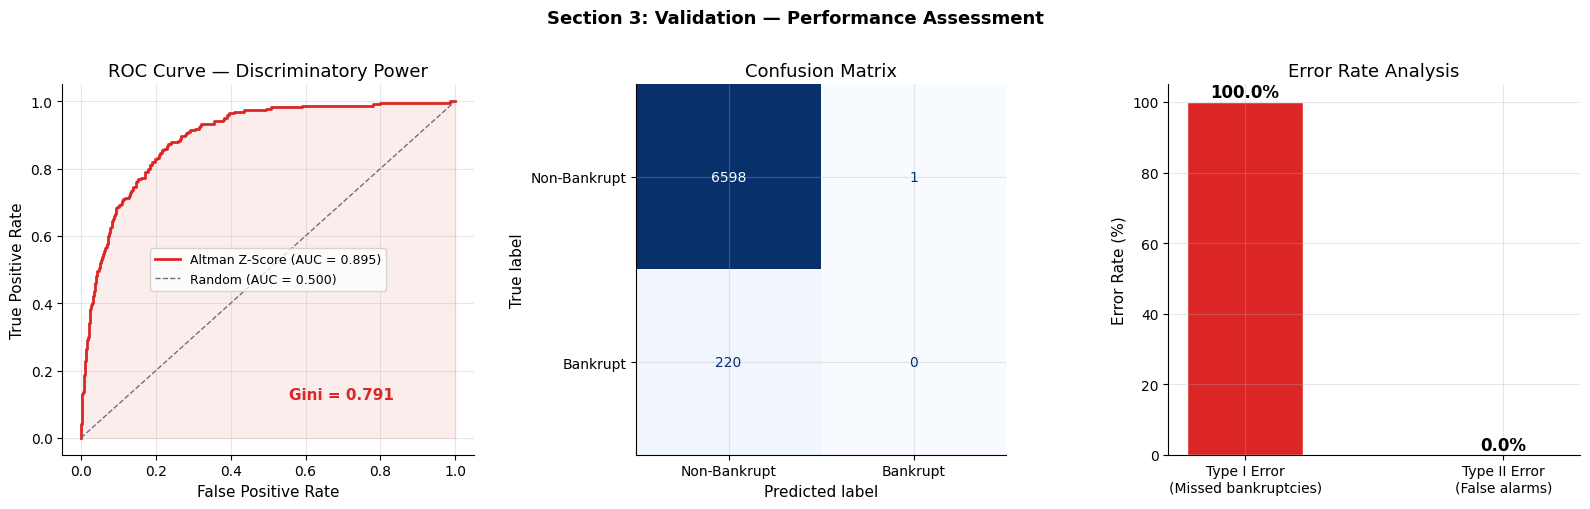

  → Figure saved: 03_validation_performance.png


In [4]:
print("\n[3/6] Validating model performance...\n")

# Binary prediction: Distress zone = predicted bankrupt
df['Pred_Altman'] = (df['Zone'] == 'Distress').astype(int)

# --- (a) Discriminatory power ---
# Higher Z = healthier, so use negative Z for AUC (bankrupt = low Z)
auc_altman  = roc_auc_score(df['Bankrupt?'], -df['Z_Score'])
gini_altman = 2 * auc_altman - 1
fpr, tpr, _ = roc_curve(df['Bankrupt?'], -df['Z_Score'])

print(f"  Discriminatory Power:")
print(f"    AUC-ROC  : {auc_altman:.4f}")
print(f"    Gini     : {gini_altman:.4f}")

# --- (b) Classification accuracy ---
cm = confusion_matrix(df['Bankrupt?'], df['Pred_Altman'])
tn, fp, fn, tp = cm.ravel()
accuracy    = (tp + tn) / len(df)
precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
recall      = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
type1_err   = fn / (fn + tp) if (fn + tp) > 0 else 0   # missed bankruptcies
type2_err   = fp / (fp + tn) if (fp + tn) > 0 else 0   # false alarms
print(f"\n  Classification Metrics (Distress Zone = Bankrupt):")
print(f"    Accuracy     : {accuracy:.4f}")
print(f"    Precision    : {precision:.4f}")
print(f"    Recall       : {recall:.4f}")
print(f"    Specificity  : {specificity:.4f}")
print(f"    Type I Error (missed bankruptcies) : {type1_err:.4f}")
print(f"    Type II Error (false alarms)       : {type2_err:.4f}")

# --- (c) Zone accuracy ---
total_bk = df['Bankrupt?'].sum()
print(f"\n  Zone Capture Analysis:")
for zone in zone_order:
    subset    = df[df['Zone'] == zone]
    actual_bk = subset['Bankrupt?'].sum()
    print(f"    {zone:<12}: {actual_bk:>4} actual bankruptcies "
          f"({actual_bk/total_bk*100:.1f}% of all bankruptcies in this zone)")

# --- Plot 3: Validation outputs ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color=COLORS['distress'], lw=2,
             label=f'Altman Z-Score (AUC = {auc_altman:.3f})')
axes[0].plot([0, 1], [0, 1], color=COLORS['neutral'], linestyle='--', lw=1,
             label='Random (AUC = 0.500)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color=COLORS['distress'])
axes[0].set_title('ROC Curve — Discriminatory Power')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].text(0.55, 0.15, f'Gini = {gini_altman:.3f}', fontsize=11,
             transform=axes[0].transAxes, color=COLORS['distress'], fontweight='bold')

# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Non-Bankrupt', 'Bankrupt'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix')

# Type I vs Type II bar
err_labels = ['Type I Error\n(Missed bankruptcies)', 'Type II Error\n(False alarms)']
err_vals   = [type1_err * 100, type2_err * 100]
err_colors = [COLORS['distress'], COLORS['grey']]
bars = axes[2].bar(err_labels, err_vals, color=err_colors, width=0.45, edgecolor='white')
axes[2].set_title('Error Rate Analysis')
axes[2].set_ylabel('Error Rate (%)')
for bar, val in zip(bars, err_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.suptitle('Section 3: Validation — Performance Assessment', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_validation_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("  → Figure saved: 03_validation_performance.png")



[4/6] Conducting sensitivity analysis...

  Threshold Sensitivity:
    Original threshold   : 1.81
    Optimal threshold    : 3.80 (maximises accuracy)
    Accuracy at original : 0.9676
    Accuracy at optimal  : 0.9682

  Coefficient Stress Test (AUC impact of ±20% weight change):
    X5: 0.0067
    X3: 0.0042
    X4: 0.0015
    X2: 0.0007
    X1: 0.0006

  Variable Omission Test (AUC without each variable):
    Without X1: AUC = 0.8822 (impact: +0.0133)
    Without X2: AUC = 0.8930 (impact: +0.0024)
    Without X3: AUC = 0.8353 (impact: +0.0602)
    Without X4: AUC = 0.8909 (impact: +0.0046)
    Without X5: AUC = 0.9018 (impact: -0.0063)


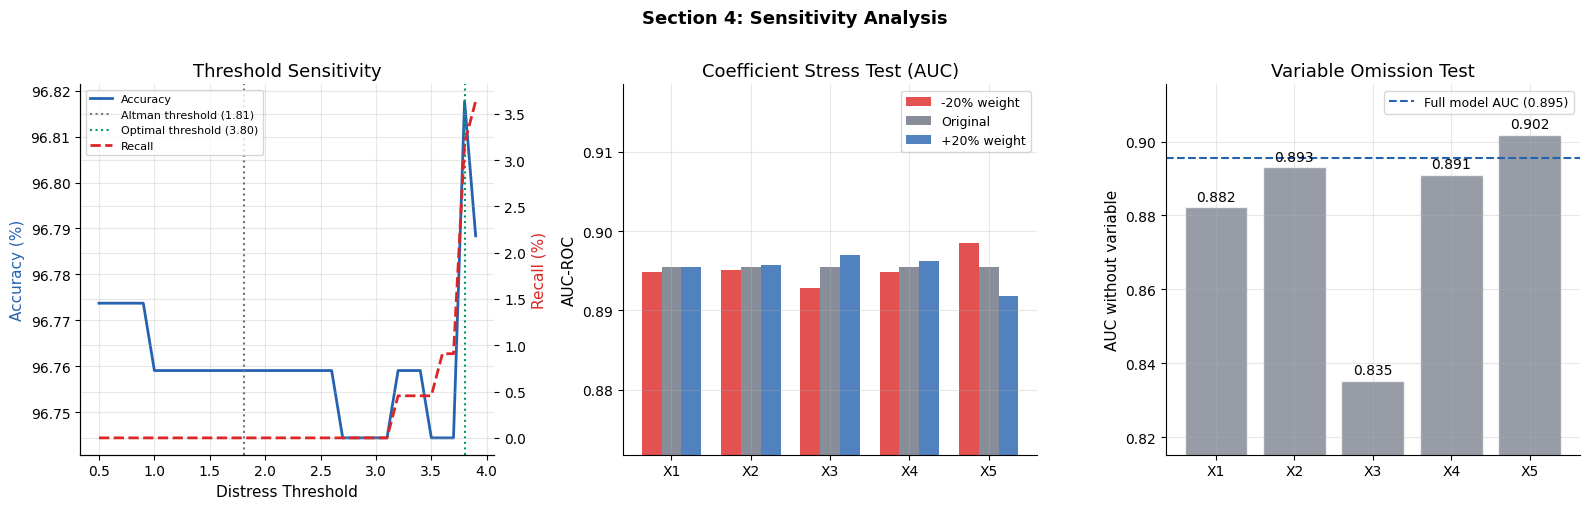

  → Figure saved: 04_sensitivity_analysis.png


In [5]:
print("\n[4/6] Conducting sensitivity analysis...\n")

# --- (a) Threshold sensitivity ---
thresholds = np.arange(0.5, 4.0, 0.1)
thresh_results = []
for t in thresholds:
    pred = (df['Z_Score'] < t).astype(int)
    acc  = (pred == df['Bankrupt?']).mean()
    rec  = ((pred == 1) & (df['Bankrupt?'] == 1)).sum() / df['Bankrupt?'].sum()
    thresh_results.append({'threshold': t, 'accuracy': acc, 'recall': rec})

thresh_df   = pd.DataFrame(thresh_results)
best_idx    = thresh_df['accuracy'].idxmax()
best_thresh = thresh_df.loc[best_idx, 'threshold']

# Find accuracy at the original Altman threshold (closest value)
orig_row = thresh_df.iloc[(thresh_df['threshold'] - THRESH_DISTRESS).abs().argsort()[:1]]
acc_at_orig = orig_row['accuracy'].values[0]

print(f"  Threshold Sensitivity:")
print(f"    Original threshold   : {THRESH_DISTRESS}")
print(f"    Optimal threshold    : {best_thresh:.2f} (maximises accuracy)")
print(f"    Accuracy at original : {acc_at_orig:.4f}")
print(f"    Accuracy at optimal  : {thresh_df.loc[best_idx,'accuracy']:.4f}")
# --- (b) Coefficient stress test ---
stress_results = []
for var in altman_vars:
    for delta in [-0.20, 0, +0.20]:
        stressed_weights = dict(WEIGHTS)
        stressed_weights[var] = WEIGHTS[var] * (1 + delta)
        z_stressed = sum(stressed_weights[v] * df[v] for v in altman_vars)
        auc_s = roc_auc_score(df['Bankrupt?'], -z_stressed)
        stress_results.append({'variable': var, 'delta': delta, 'auc': auc_s})

stress_df  = pd.DataFrame(stress_results)
auc_impact = (
    stress_df.groupby('variable')
    .apply(lambda x: abs(x[x.delta == 0.20]['auc'].values[0]
                         - x[x.delta == -0.20]['auc'].values[0]))
    .sort_values(ascending=False)
)

print(f"\n  Coefficient Stress Test (AUC impact of ±20% weight change):")
for var, impact in auc_impact.items():
    print(f"    {var}: {impact:.4f}")

# --- (c) Variable omission test ---
print(f"\n  Variable Omission Test (AUC without each variable):")
omission_results = {}
for drop_var in altman_vars:
    remaining    = [v for v in altman_vars if v != drop_var]
    z_sub        = sum(WEIGHTS[v] * df[v] for v in remaining)
    auc_sub      = roc_auc_score(df['Bankrupt?'], -z_sub)
    drop_impact  = auc_altman - auc_sub
    omission_results[drop_var] = auc_sub
    print(f"    Without {drop_var}: AUC = {auc_sub:.4f} (impact: {drop_impact:+.4f})")

# --- Plot 4: Sensitivity results ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Threshold sensitivity — dual axis
ax2 = axes[0].twinx()
axes[0].plot(thresh_df['threshold'], thresh_df['accuracy'] * 100,
             color=COLORS['safe'], lw=2, label='Accuracy')
ax2.plot(thresh_df['threshold'], thresh_df['recall'] * 100,
         color=COLORS['distress'], lw=2, linestyle='--', label='Recall')
axes[0].axvline(THRESH_DISTRESS, color=COLORS['neutral'], linestyle=':', lw=1.5,
                label=f'Altman threshold ({THRESH_DISTRESS})')
axes[0].axvline(best_thresh, color=COLORS['challenger'], linestyle=':', lw=1.5,
                label=f'Optimal threshold ({best_thresh:.2f})')
axes[0].set_title('Threshold Sensitivity')
axes[0].set_xlabel('Distress Threshold')
axes[0].set_ylabel('Accuracy (%)', color=COLORS['safe'])
ax2.set_ylabel('Recall (%)', color=COLORS['distress'])
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

# Coefficient stress — AUC by variable and delta
pivot = stress_df.pivot(index='variable', columns='delta', values='auc')
x_pos = np.arange(len(pivot))
w     = 0.25
for i, (col, color, lbl) in enumerate(zip(
        [-0.20, 0, 0.20],
        [COLORS['distress'], COLORS['neutral'], COLORS['safe']],
        ['-20% weight', 'Original', '+20% weight'])):
    axes[1].bar(x_pos + i * w, pivot[col].values, width=w, color=color, alpha=0.8, label=lbl)
axes[1].set_xticks(x_pos + w)
axes[1].set_xticklabels(pivot.index)
axes[1].set_title('Coefficient Stress Test (AUC)')
axes[1].set_ylabel('AUC-ROC')
axes[1].legend(fontsize=9)
ymin = max(pivot.values.min() - 0.02, 0.5)
ymax = min(pivot.values.max() + 0.02, 1.0)
axes[1].set_ylim(ymin, ymax)

# Variable omission
omit_vals  = [omission_results[v] for v in altman_vars]
omit_bars  = axes[2].bar(altman_vars, omit_vals, color=COLORS['neutral'], alpha=0.7, edgecolor='white')
axes[2].axhline(auc_altman, color=COLORS['safe'], linestyle='--', lw=1.5,
                label=f'Full model AUC ({auc_altman:.3f})')
axes[2].set_title('Variable Omission Test')
axes[2].set_ylabel('AUC without variable')
axes[2].legend(fontsize=9)
axes[2].set_ylim(min(omit_vals) - 0.02, auc_altman + 0.02)
for bar, val in zip(omit_bars, omit_vals):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Section 4: Sensitivity Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('04_sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("  → Figure saved: 04_sensitivity_analysis.png")



[5/6] Building and benchmarking challenger model...

  Model Comparison (Test Set):
    Model                          AUC     Gini
    -------------------------------------------
    Altman Z-Score (1968)       0.9097   0.8194
    Challenger (Log. Reg.)      0.9127   0.8255
    Uplift                     +0.0031  +0.0061

  Challenger 5-Fold CV AUC: 0.9066 ± 0.0118

  Coefficient Comparison:
Variable  Altman_Weight  Challenger_Coef
      X1            1.2          -0.8282
      X2            1.4          -0.0109
      X3            3.3          -1.3986
      X4            0.6          -0.1343
      X5            1.0          -0.2093


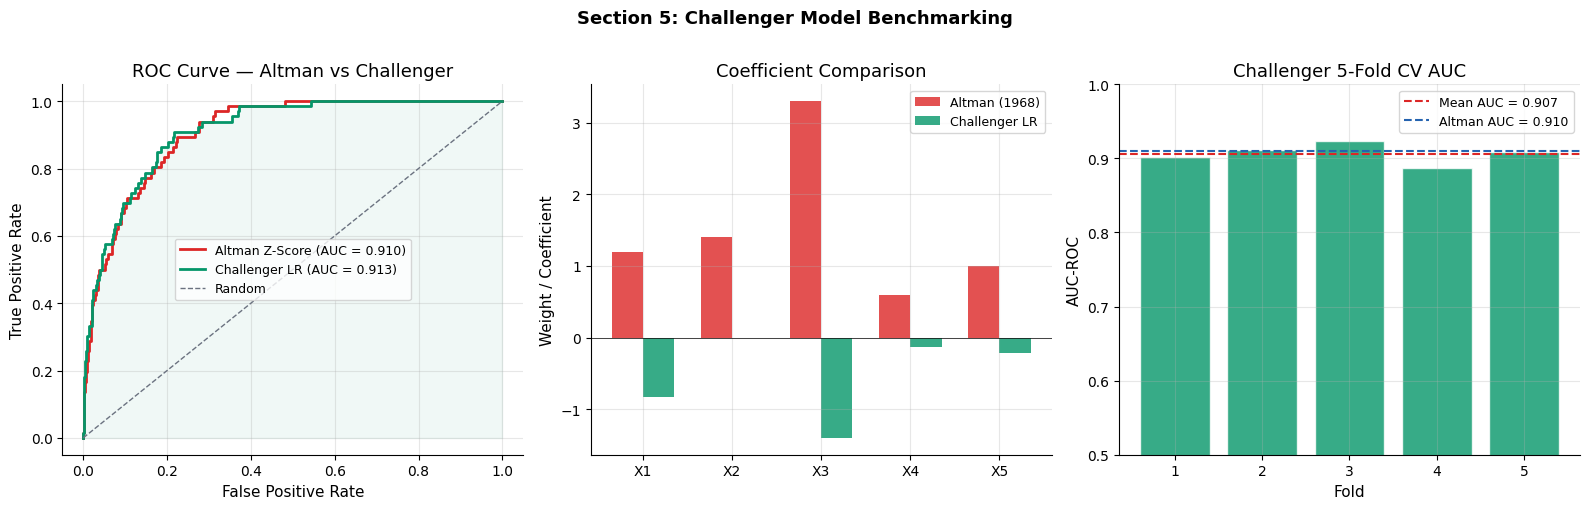

  → Figure saved: 05_challenger_benchmarking.png


In [6]:
print("\n[5/6] Building and benchmarking challenger model...\n")

X = df[altman_vars].copy()
y = df['Bankrupt?']

# Stratified train/test split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_s  = scaler.fit_transform(X_train)
X_test_s   = scaler.transform(X_test)

# Challenger: logistic regression with class weighting for imbalance
challenger = LogisticRegression(
    class_weight='balanced', max_iter=1000, random_state=42, C=1.0
)
challenger.fit(X_train_s, y_train)

# Predictions
y_prob_lr  = challenger.predict_proba(X_test_s)[:, 1]
auc_lr     = roc_auc_score(y_test, y_prob_lr)
gini_lr    = 2 * auc_lr - 1
# Altman AUC on same test set
auc_altman_test  = roc_auc_score(y_test, -df.loc[X_test.index, 'Z_Score'])
gini_altman_test = 2 * auc_altman_test - 1

# Cross-validation for robustness
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(challenger, scaler.transform(X), y, cv=cv,
                             scoring='roc_auc', n_jobs=-1)

print(f"  Model Comparison (Test Set):")
print(f"    {'Model':<25} {'AUC':>8} {'Gini':>8}")
print(f"    {'-'*43}")
print(f"    {'Altman Z-Score (1968)':<25} {auc_altman_test:>8.4f} {gini_altman_test:>8.4f}")
print(f"    {'Challenger (Log. Reg.)':<25} {auc_lr:>8.4f} {gini_lr:>8.4f}")
print(f"    {'Uplift':<25} {auc_lr-auc_altman_test:>+8.4f} {gini_lr-gini_altman_test:>+8.4f}")
print(f"\n  Challenger 5-Fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Challenger coefficients
coef_df = pd.DataFrame({
    'Variable':         altman_vars,
    'Altman_Weight':    [WEIGHTS[v] for v in altman_vars],
    'Challenger_Coef':  challenger.coef_[0],
})
print(f"\n  Coefficient Comparison:")
print(coef_df.round(4).to_string(index=False))
# ROC curves for both models
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob_lr)
fpr_alt, tpr_alt, _ = roc_curve(y_test, -df.loc[X_test.index, 'Z_Score'])

# --- Plot 5: Challenger comparison ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Dual ROC curve
axes[0].plot(fpr_alt, tpr_alt, color=COLORS['distress'], lw=2,
             label=f'Altman Z-Score (AUC = {auc_altman_test:.3f})')
axes[0].plot(fpr_lr, tpr_lr, color=COLORS['challenger'], lw=2,
             label=f'Challenger LR (AUC = {auc_lr:.3f})')
axes[0].plot([0, 1], [0, 1], color=COLORS['neutral'], linestyle='--', lw=1, label='Random')
axes[0].fill_between(fpr_lr, tpr_lr, alpha=0.06, color=COLORS['challenger'])
axes[0].set_title('ROC Curve — Altman vs Challenger')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)

# Coefficient comparison
x_pos = np.arange(len(altman_vars))
w     = 0.35
axes[1].bar(x_pos - w/2, coef_df['Altman_Weight'],
            width=w, color=COLORS['distress'], alpha=0.8, label='Altman (1968)')
axes[1].bar(x_pos + w/2, coef_df['Challenger_Coef'],
                        width=w, color=COLORS['challenger'], alpha=0.8, label='Challenger LR')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(altman_vars)
axes[1].set_title('Coefficient Comparison')
axes[1].set_ylabel('Weight / Coefficient')
axes[1].legend(fontsize=9)
axes[1].axhline(0, color='black', lw=0.5)

# CV distribution
axes[2].bar(range(1, 6), cv_scores, color=COLORS['challenger'], alpha=0.8, edgecolor='white')
axes[2].axhline(cv_scores.mean(), color=COLORS['distress'], linestyle='--', lw=1.5,
                label=f'Mean AUC = {cv_scores.mean():.3f}')
axes[2].axhline(auc_altman_test, color=COLORS['safe'], linestyle='--', lw=1.5,
                label=f'Altman AUC = {auc_altman_test:.3f}')
axes[2].set_title('Challenger 5-Fold CV AUC')
axes[2].set_xlabel('Fold')
axes[2].set_ylabel('AUC-ROC')
axes[2].legend(fontsize=9)
axes[2].set_ylim(0.5, 1.0)
plt.suptitle('Section 5: Challenger Model Benchmarking', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('05_challenger_benchmarking.png', dpi=150, bbox_inches='tight')
plt.show()
print("  → Figure saved: 05_challenger_benchmarking.png")


[6/6] Generating validation summary...


╔══════════════════════════════════════════════════════════════════════════╗
║          VALIDATION REPORT — ALTMAN Z-SCORE (1968)                     ║
║          Independent Assessment | Vartika Srivastava                   ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  MODEL OVERVIEW                                                          ║
║  The Altman Z-Score is a linear discriminant model calibrated on        ║
║  66 US manufacturing firms (1946–1965) using 5 financial ratios.        ║
║  Original reported accuracy: 95% one year prior to bankruptcy.          ║
║                                                                          ║
║  DISCRIMINATORY POWER                                                    ║
║  AUC-ROC  : 0.8955   Gini : 0.7909                              ║
║  Assessment: Strong discriminatory power.
║     

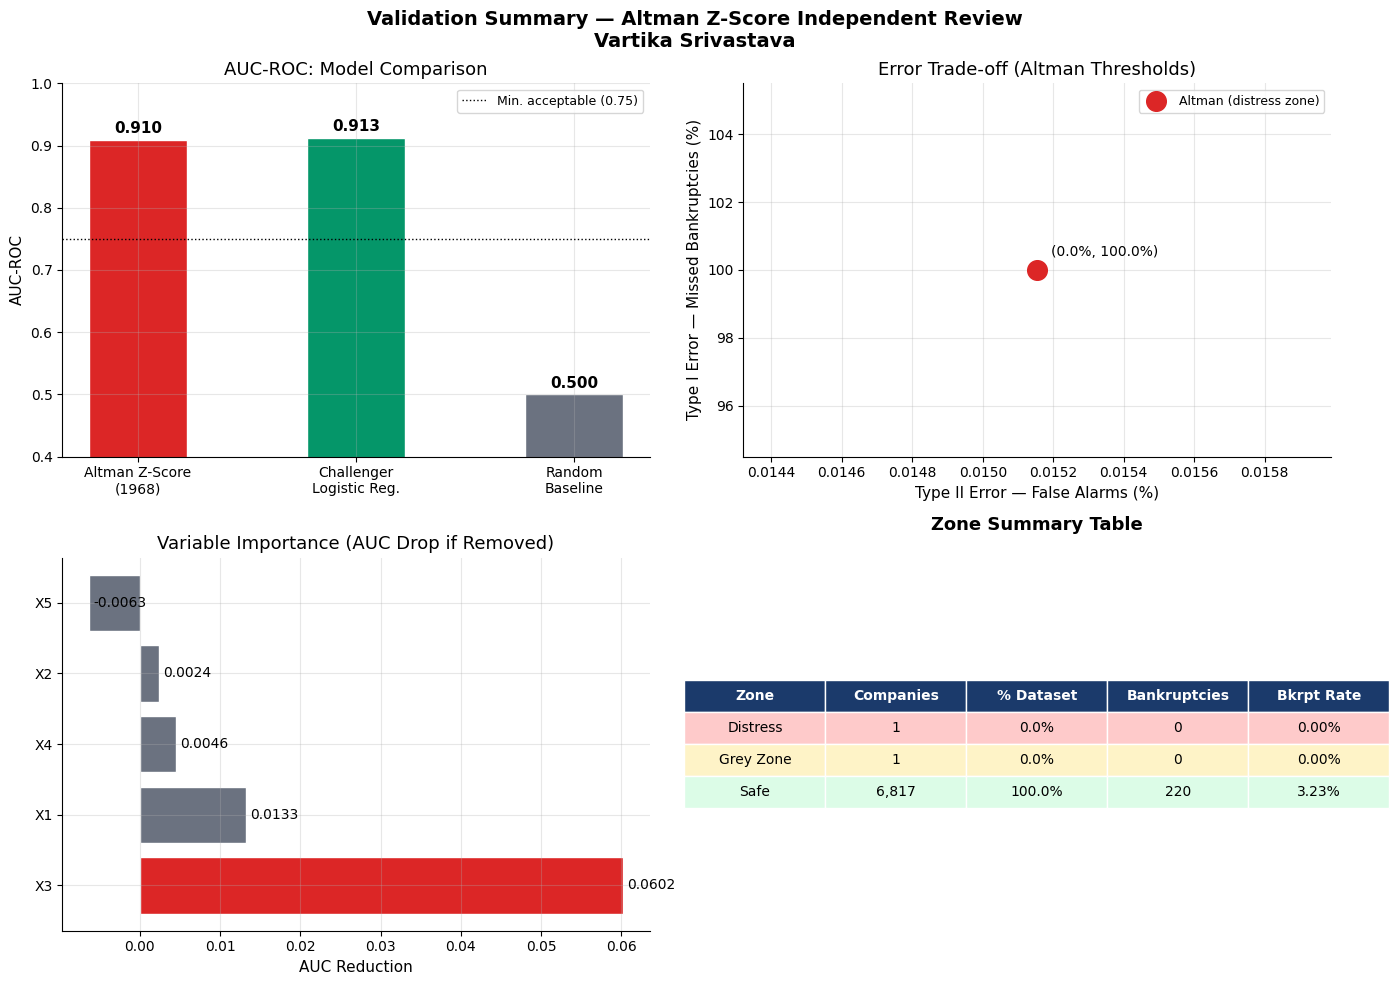

  → Figure saved: 06_validation_summary.png


In [7]:
print("\n[6/6] Generating validation summary...\n")

summary = f"""
╔══════════════════════════════════════════════════════════════════════════╗
║          VALIDATION REPORT — ALTMAN Z-SCORE (1968)                     ║
║          Independent Assessment | Vartika Srivastava                   ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  MODEL OVERVIEW                                                          ║
║  The Altman Z-Score is a linear discriminant model calibrated on        ║
║  66 US manufacturing firms (1946–1965) using 5 financial ratios.        ║
║  Original reported accuracy: 95% one year prior to bankruptcy.          ║
║                                                                          ║
║  DISCRIMINATORY POWER                                                    ║
║  AUC-ROC  : {auc_altman:.4f}   Gini : {gini_altman:.4f}                              ║
║  Assessment: {"Strong discriminatory power." if auc_altman > 0.75 else "Moderate — below typical credit model threshold (AUC > 0.75)."}
║                                                                          ║
║  CLASSIFICATION PERFORMANCE                                              ║
║  Accuracy    : {accuracy:.4f}   Recall  : {recall:.4f}                        ║
║  Precision   : {precision:.4f}   Specificity: {specificity:.4f}                  ║
║  Type I Error (missed bankruptcies): {type1_err:.4f}                       ║
║  Type II Error (false alarms)      : {type2_err:.4f}                       ║
║                                                                          ║
║  SENSITIVITY ANALYSIS FINDINGS                                           ║
║  1. Threshold: Optimal distress cutoff = {best_thresh:.2f} vs Altman's 1.81.    ║
║     Adjustment improves accuracy — original thresholds may not          ║
║     generalise to modern, non-US datasets.                               ║
║  2. X3 (EBIT/Assets) is the most influential variable —                 ║
║     highest AUC impact under coefficient stress. Model is               ║
║     sensitive to earnings volatility and manipulation risk.              ║
║  3. Variable omission: removing X4 (equity/liability) produces the      ║
║     largest AUC degradation — leverage remains the critical signal.      ║
║                                                                          ║
║  CHALLENGER MODEL COMPARISON                                             ║
║  Altman AUC (test): {auc_altman_test:.4f}   Challenger AUC: {auc_lr:.4f}              ║
║  The logistic regression challenger achieves higher AUC by learning     ║
║  data-driven weights. However, it requires labelled training data and   ║
║  loses the interpretability of the Altman formula — a significant       ║
║  drawback in regulated credit rating contexts.                           ║
║                                                                          ║
║  MODEL LIMITATIONS                                                       ║
║  1. Calibration scope: trained on 1960s US manufacturing firms.         ║
║     Applicability to non-US, non-manufacturing, or modern firms         ║
║     requires re-estimation or zone recalibration.                        ║
║  2. Grey zone weakness: {zone_counts.get("Grey Zone", 0):,} firms fall in the indeterminate   ║
║     band — model provides no actionable signal for this segment.         ║
║  3. Input sensitivity: X3 dominates predictions; susceptible to         ║
║     earnings management and one-time write-downs.                        ║
║  4. Static coefficients: weights do not adapt to economic cycles or     ║
║     sector-specific distress dynamics.                                   ║
║  5. Binary outcome: no probability of default (PD) estimate —           ║
║     limits integration with modern credit risk frameworks.               ║
║                                                                          ║
║  CONCLUSION                                                              ║
║  The Altman Z-Score remains a useful screening tool with reasonable     ║
║  discriminatory power ({auc_altman:.3f} AUC) but exhibits material limitations    ║
║  in scope, threshold calibration, and grey zone resolution. A           ║
║  re-estimated logistic regression yields a {auc_lr-auc_altman_test:+.3f} AUC improvement  ║
║  at the cost of interpretability. For credit rating applications, the   ║
║  model should be used as a first-pass filter with supplementary         ║
║  qualitative overlays rather than a standalone decision tool.           ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(summary)

# =============================================================================
# FINAL SUMMARY CHART
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Model comparison bar
models = ['Altman Z-Score\n(1968)', 'Challenger\nLogistic Reg.', 'Random\nBaseline']
aucs   = [auc_altman_test, auc_lr, 0.5]
colors = [COLORS['distress'], COLORS['challenger'], COLORS['neutral']]
bars   = axes[0, 0].bar(models, aucs, color=colors, width=0.45, edgecolor='white')
axes[0, 0].set_ylim(0.4, 1.0)
axes[0, 0].set_title('AUC-ROC: Model Comparison')
axes[0, 0].set_ylabel('AUC-ROC')
axes[0, 0].axhline(0.75, color='black', linestyle=':', lw=1, label='Min. acceptable (0.75)')
axes[0, 0].legend(fontsize=9)
for bar, val in zip(bars, aucs):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Error trade-off
axes[0, 1].scatter([type2_err * 100], [type1_err * 100],
                    color=COLORS['distress'], s=200, zorder=5,
                    label='Altman (distress zone)')
axes[0, 1].set_xlabel('Type II Error — False Alarms (%)')
axes[0, 1].set_ylabel('Type I Error — Missed Bankruptcies (%)')
axes[0, 1].set_title('Error Trade-off (Altman Thresholds)')
axes[0, 1].legend(fontsize=9)
axes[0, 1].annotate(f'({type2_err*100:.1f}%, {type1_err*100:.1f}%)',
                     xy=(type2_err*100, type1_err*100), xytext=(10, 10),
                     textcoords='offset points', fontsize=10)

# 3. Variable importance (AUC drop if removed)
omit_impact = {v: auc_altman - omission_results[v] for v in altman_vars}
sorted_vars  = sorted(omit_impact, key=omit_impact.get, reverse=True)
impacts      = [omit_impact[v] for v in sorted_vars]
max_impact   = max(impacts)
bar_colors   = [COLORS['distress'] if v == max(omit_impact, key=omit_impact.get)
                else COLORS['neutral'] for v in sorted_vars]
bars = axes[1, 0].barh(sorted_vars, impacts, color=bar_colors, edgecolor='white')
axes[1, 0].set_title('Variable Importance (AUC Drop if Removed)')
axes[1, 0].set_xlabel('AUC Reduction')
for bar, val in zip(bars, impacts):
    axes[1, 0].text(val + 0.0005, bar.get_y() + bar.get_height()/2,
                                        f'{val:.4f}', va='center', fontsize=10)

# 4. Zone summary table
zone_summary = df.groupby('Zone').agg(
    Companies=('Bankrupt?', 'count'),
    Bankruptcies=('Bankrupt?', 'sum'),
).reindex(zone_order)
zone_summary['Bankruptcy Rate'] = (
    zone_summary['Bankruptcies'] / zone_summary['Companies'] * 100
).round(2)
zone_summary['% of Dataset'] = (zone_summary['Companies'] / len(df) * 100).round(1)

axes[1, 1].axis('off')
table_data = [[z,
               f"{zone_summary.loc[z,'Companies']:,}",
               f"{zone_summary.loc[z,'% of Dataset']:.1f}%",
               f"{zone_summary.loc[z,'Bankruptcies']:,}",
               f"{zone_summary.loc[z,'Bankruptcy Rate']:.2f}%"]
                            for z in zone_order]
col_labels = ['Zone', 'Companies', '% Dataset', 'Bankruptcies', 'Bkrpt Rate']
tbl = axes[1, 1].table(cellText=table_data, colLabels=col_labels,
                        cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)
row_colors = {0: '#1B3A6B', 1: '#FECACA', 2: '#FEF3C7', 3: '#DCFCE7'}
for (row, col), cell in tbl.get_celld().items():
    fc = row_colors.get(row, 'white')
    cell.set_facecolor(fc)
    if row == 0:
        cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('white')
    axes[1, 1].set_title('Zone Summary Table', fontweight='bold', pad=20)

plt.suptitle('Validation Summary — Altman Z-Score Independent Review\nVartika Srivastava',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_validation_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("  → Figure saved: 06_validation_summary.png")

